In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 60)
pd.options.display.float_format = '{:.6f}'.format


mkdir -p failed for path /home/vscode/.config/matplotlib: [Errno 13] Permission denied: '/home/vscode/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-mnm711kd because there was an issue with the default path (/home/vscode/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start


ROOT = find_repo_root(Path.cwd())
OUTPUT = ROOT / 'model_artifacts' / 'simple_spatial' / 'classification_perturbation.csv'

result = pd.read_csv(OUTPUT)


result = result.sort_values('accuracy_drop', ascending=False).reset_index(drop=True)
result['rank'] = np.arange(1, len(result) + 1)
result['cv'] = np.where(result['accuracy_drop'] > 0, result['accuracy_drop_std'] / result['accuracy_drop'], np.nan)

print('Perturbation report:', OUTPUT)
display(result)


Perturbation report: /workspaces/be-bper-ai-toolchain-bseq-app/model_artifacts/simple_spatial/classification_perturbation.csv


,variable,importance_rank,clean_accuracy,perturbed_accuracy,accuracy_drop,accuracy_drop_std,clean_macro_f1,perturbed_macro_f1,macro_f1_drop,prediction_flip_rate,prediction_flip_rate_std,rank,cv
0,merchant,1,0.987500,0.419229,0.568271,0.004315,0.987499,0.390171,0.597328,0.581083,0.004571,1,0.007593
1,cocau,2,0.987500,0.728688,0.258813,0.001392,0.987499,0.657285,0.330214,0.266437,0.001732,2,0.005379
2,importo,3,0.987500,0.743083,0.244417,0.005429,0.987499,0.745206,0.242293,0.257500,0.005738,3,0.022212
3,delta_t,4,0.987500,0.987542,-0.000042,0.000243,0.987499,0.987541,-0.000042,0.000417,0.000186,4,NaN


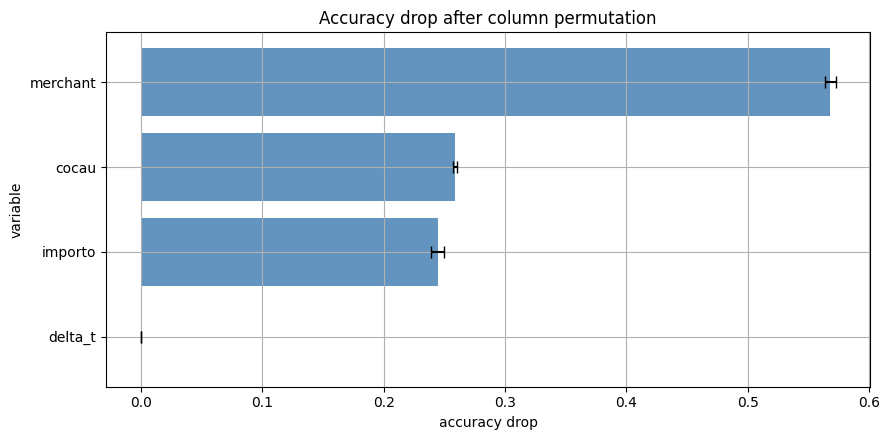

In [3]:
plot_df = result.sort_values('accuracy_drop', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    plot_df['variable'],
    plot_df['accuracy_drop'],
    xerr=plot_df['accuracy_drop_std'],
    color='steelblue',
    ecolor='black',
    alpha=0.85,
    capsize=4,
)
ax.set_xlabel('accuracy drop')
ax.set_ylabel('variable')
ax.set_title('Accuracy drop after column permutation')
plt.tight_layout()
plt.show()


In [4]:
leader = result.iloc[0]
runner_up = result.iloc[1] if len(result) > 1 else None
total_accuracy_drop = result['accuracy_drop'].sum()

insights = pd.DataFrame([
    {
        'top_variable': leader['variable'],
        'top_accuracy_drop': leader['accuracy_drop'],
        'top_accuracy_drop_std': leader['accuracy_drop_std'],
        'share_of_total_accuracy_drop': leader['accuracy_drop'] / total_accuracy_drop if total_accuracy_drop else np.nan,
        'gap_vs_second': leader['accuracy_drop'] - runner_up['accuracy_drop'] if runner_up is not None else np.nan,
    }
])
display(insights)

result.assign(
    relative_to_top=np.where(leader['accuracy_drop'] > 0, result['accuracy_drop'] / leader['accuracy_drop'], np.nan)
)[['variable', 'accuracy_drop', 'accuracy_drop_std', 'relative_to_top', 'cv']]


,top_variable,top_accuracy_drop,top_accuracy_drop_std,share_of_total_accuracy_drop,gap_vs_second
0,merchant,0.568271,0.004315,0.530371,0.309458


,variable,accuracy_drop,accuracy_drop_std,relative_to_top,cv
0,merchant,0.568271,0.004315,1.000000,0.007593
1,cocau,0.258813,0.001392,0.455439,0.005379
2,importo,0.244417,0.005429,0.430106,0.022212
3,delta_t,-0.000042,0.000243,-0.000073,NaN
